# 　基于MNIST数据集的更新方法的比较

In [1]:

import sys, os
sys.path.append(os.pardir)
import numpy as np
from typing import Dict, List
from libs.network import NeuralNet
from libs.trainer import Trainer
from libs.optimizer import Optimizer
from libs.util import smooth_curve


In [2]:
# 加载数据集
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)


# 训练数据集和测试数据集都只取100条(缩短训练时间)
# x_train, t_train = x_train[:100], t_train[:100]
# x_test, t_test = x_test[:100], t_test[:100]

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)


save_file: /Users/simeon/WorkSpace/Projects/Practice/DeepLearnStudy/example/../dataset/data/mnist.pkl
(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


In [3]:
def start_train(optimizer: str, optimizer_param: Dict, hidden_size_list: List[int]=[100, 100], epochs: int=5, mini_batch_size: int=100) -> List[float]:
    trainer = Trainer(
        network=NeuralNet(input_size=x_train.shape[1], hidden_size_list=hidden_size_list, output_size=t_train.shape[1]),
        x_train=x_train,
        t_train=t_train,
        x_test=x_test,
        t_test=t_test,
        optimizer=optimizer,
        optimizer_param=optimizer_param,
        epochs=epochs,
        mini_batch_size=mini_batch_size,
        verbose=True
    )
    trainer.train()
    return trainer.train_loss_list, trainer.train_acc_list, trainer.test_acc_list

========= Using SGD optimizer =========
网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
	epoch:1, loss:272.2584166591689, train acc:0.12121666666666667, test acc:0.1245
	epoch:2, loss:51.74640602248375, train acc:0.8399166666666666, test acc:0.8469
	epoch:3, loss:38.61177325735271, train acc:0.88165, test acc:0.8864
	epoch:4, loss:22.559685843419764, train acc:0.8998, test acc:0.9023
	epoch:5, loss:42.119984268446956, train acc:0.9091, test acc:0.9114
=============== Final Test Accuracy ===============
test acc:0.9204



========= Using Momentum optimizer =========
网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:10), b3(10)
	【Softmax + Loss】
	epoch:1, loss:300.868128266766, train acc:0.12633333333333333, test acc:0.1243
	epoch:2, loss:17.34117089452636, train acc:0.92865, test acc:

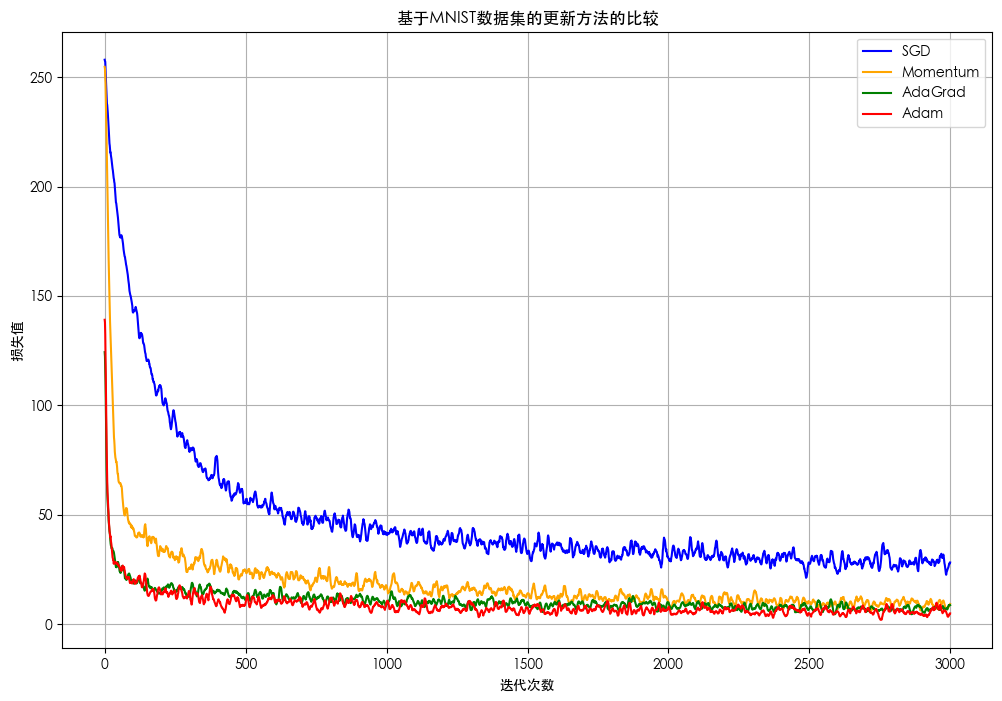

In [4]:
from libs.optimizer import SGD, Momentum, AdaGrad, Adam

# 使用 SGD 优化器
print("========= Using SGD optimizer =========")
train_loss_sgd, _, _ = start_train('sgd', {'lr': 0.01})
print("\n\n")


# 使用 Momentum 优化器
print("========= Using Momentum optimizer =========")
train_loss_momentum, _, _ = start_train('momentum', {'lr': 0.01, 'momentum': 0.9})
print("\n\n")


# 使用 AdaGrad 优化器
print("========= Using AdaGrad optimizer =========")
train_loss_adagrad, _, _ = start_train('adagrad', {'lr': 0.01})
print("\n\n")


# 使用 Adam 优化器
print("========= Using Adam optimizer =========")
train_loss_adam, _, _ = start_train('adam', {'lr': 0.01})
print("\n\n")

# 绘制损失曲线
import matplotlib.pyplot as plt
# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

plt.figure(figsize=(12, 8))
plt.plot(smooth_curve(train_loss_sgd), label='SGD', color='blue')
plt.plot(smooth_curve(train_loss_momentum), label='Momentum', color='orange')
plt.plot(smooth_curve(train_loss_adagrad), label='AdaGrad', color='green')
plt.plot(smooth_curve(train_loss_adam), label='Adam', color='red')
plt.title('基于MNIST数据集的更新方法的比较')
plt.xlabel('迭代次数')
plt.ylabel('损失值')
plt.legend()
plt.grid()
plt.show()